# Demostración: análisis de retorno de un portafolio con Python

Tarea del curso **Mercado de Capitales** · MBA · **Universidad Viña del Mar**

Este notebook es una **demostración reutilizable** de cómo usar Python y la
librería [`yfinance`](https://github.com/ranaroussi/yfinance) para analizar el
retorno y el riesgo de un portafolio de inversiones. Como caso de ejemplo se
responde, paso a paso:

> Asumiendo una inversión de **30 % en CMPC, 30 % en Copec y 40 % en Cencosud**,
> ¿cuál fue el **retorno del portafolio durante 2022**?

Para analizar otra cartera basta con cambiar `TICKERS`, `PESOS` e `INICIO/FIN`
en la celda de parámetros. La metodología completa está en
[`../docs/METODOLOGIA.md`](../docs/METODOLOGIA.md).


In [1]:
# Instala las dependencias si hace falta (descomenta):
# %pip install -r ../requirements.txt

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import yfinance as yf

pd.set_option("display.float_format", lambda x: f"{x:,.4f}")
print("yfinance", yf.__version__, "| pandas", pd.__version__)

yfinance 1.7.0 | pandas 2.3.3


## 1. Parámetros del portafolio

Descargamos desde **diciembre de 2021** para tener el precio base con el que se
calcula el primer retorno mensual de 2022.

In [2]:
TICKERS = ["CMPC.SN", "COPEC.SN", "CENCOSUD.SN"]
PESOS   = pd.Series({"CMPC.SN": 0.30, "COPEC.SN": 0.30, "CENCOSUD.SN": 0.40})

INICIO, FIN = "2021-12-01", "2022-12-31"
assert np.isclose(PESOS.sum(), 1.0)
PESOS

CMPC.SN       0.3000
COPEC.SN      0.3000
CENCOSUD.SN   0.4000
dtype: float64

## 2. Descarga de precios (cierre ajustado mensual)

Usamos **`Adj Close`**: incorpora dividendos y splits, por lo que su variación
mide el *retorno total* del accionista, no solo la ganancia de capital.

In [3]:
raw = yf.download(TICKERS, start=INICIO, end="2023-01-15", interval="1mo",
                  auto_adjust=False, progress=False)
precios = raw["Adj Close"][TICKERS]
precios = precios[precios.index <= FIN].dropna()
precios.index.name = "Fecha"
precios

Ticker,CMPC.SN,COPEC.SN,CENCOSUD.SN
Fecha,,,
2021-12-01,"1,415.4397","6,465.5742","1,186.4557"
2022-01-01,"1,456.7727","6,597.1245","1,228.0026"
2022-02-01,"1,308.7859","6,086.6323","1,223.9229"
2022-03-01,"1,444.1847","6,381.1465","1,290.5308"
2022-04-01,"1,259.8204","6,155.3535","1,243.0989"
2022-05-01,"1,411.5225","6,420.5977","1,202.4819"
2022-06-01,"1,511.6373","6,646.3989","1,063.6920"
2022-07-01,"1,517.5848","7,245.2617","1,121.0659"
2022-08-01,"1,685.1777","7,589.8540","1,141.1011"


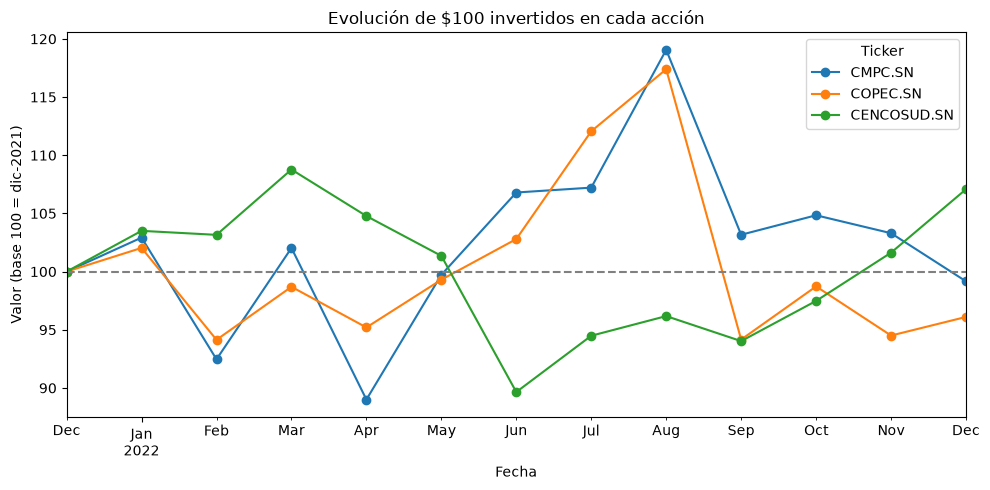

In [4]:
ax = (precios / precios.iloc[0] * 100).plot(marker="o", figsize=(10, 5))
ax.axhline(100, color="grey", ls="--")
ax.set_title("Evolución de $100 invertidos en cada acción")
ax.set_ylabel("Valor (base 100 = dic-2021)")
plt.tight_layout(); plt.show()

## 3. Retornos mensuales simples

$$R_{i,t} = \dfrac{P_{i,t}}{P_{i,t-1}} - 1$$

In [5]:
retornos = precios.pct_change().dropna()
(retornos * 100).round(2)

Ticker,CMPC.SN,COPEC.SN,CENCOSUD.SN
Fecha,,,
2022-01-01,2.9200,2.0300,3.5000
2022-02-01,-10.1600,-7.7400,-0.3300
2022-03-01,10.3500,4.8400,5.4400
2022-04-01,-12.7700,-3.5400,-3.6800
2022-05-01,12.0400,4.3100,-3.2700
2022-06-01,7.0900,3.5200,-11.5400
2022-07-01,0.3900,9.0100,5.3900
2022-08-01,11.0400,4.7600,1.7900
2022-09-01,-13.3500,-19.7900,-2.2300


## 4. Retorno de cada acción en 2022 (comprar y mantener)

In [6]:
retorno_anual = precios.iloc[-1] / precios.iloc[0] - 1
tabla = pd.DataFrame({
    "Peso": PESOS,
    "Retorno 2022 (%)": (retorno_anual * 100).round(2),
    "Contribucion (pp)": (PESOS * retorno_anual * 100).round(2),
})
tabla.loc["PORTAFOLIO"] = [tabla["Peso"].sum(), np.nan, tabla["Contribucion (pp)"].sum().round(2)]
tabla

,Peso,Retorno 2022 (%),Contribucion (pp)
CMPC.SN,0.3000,-0.8300,-0.2500
COPEC.SN,0.3000,-3.9000,-1.1700
CENCOSUD.SN,0.4000,7.0800,2.8300
PORTAFOLIO,1.0000,NaN,1.4100


## 5. Retorno del portafolio

### 5.1 Comprar y mantener — respuesta principal

$$R_p^{2022} = \sum_i w_i\, R_i^{2022}$$

In [7]:
R_buy_and_hold = float((PESOS * retorno_anual).sum())
print(f"Retorno del portafolio 2022 (comprar y mantener): {R_buy_and_hold:.2%}")

Retorno del portafolio 2022 (comprar y mantener): 1.41%


### 5.2 Rebalanceo mensual a 30/30/40

$$R_{p,t} = \sum_i w_i\, R_{i,t}
\qquad
R_p^{2022} = \prod_{t=1}^{12}(1 + R_{p,t}) - 1$$

In [8]:
retorno_port_mensual = (retornos * PESOS).sum(axis=1)
R_rebalanceo = float((1 + retorno_port_mensual).prod() - 1)
print(f"Retorno del portafolio 2022 (rebalanceo mensual): {R_rebalanceo:.2%}")
(retorno_port_mensual * 100).round(2).to_frame("Retorno portafolio (%)")

Retorno del portafolio 2022 (rebalanceo mensual): 2.73%


,Retorno portafolio (%)
Fecha,
2022-01-01,2.8900
2022-02-01,-5.5000
2022-03-01,6.7300
2022-04-01,-6.3600
2022-05-01,3.6000
2022-06-01,-1.4300
2022-07-01,4.9800
2022-08-01,5.4500
2022-09-01,-10.8300


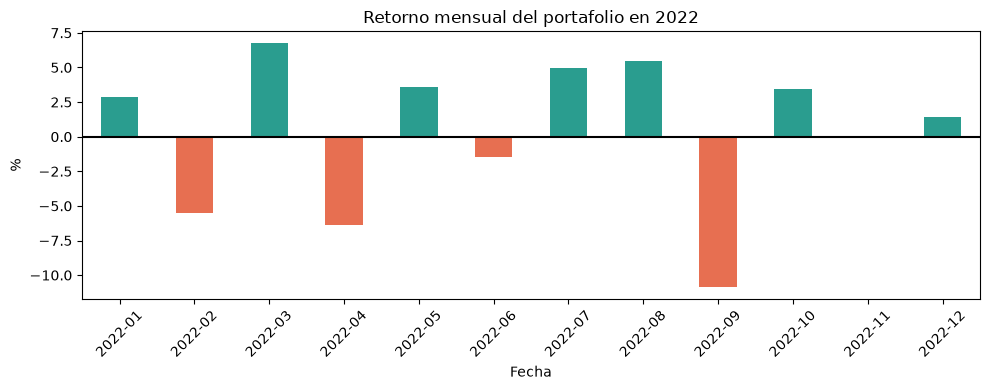

In [9]:
colores = ["#2a9d8f" if v >= 0 else "#e76f51" for v in retorno_port_mensual]
ax = retorno_port_mensual.mul(100).plot(kind="bar", color=colores, figsize=(10, 4))
ax.set_xticklabels([d.strftime("%Y-%m") for d in retorno_port_mensual.index], rotation=45)
ax.axhline(0, color="black"); ax.set_ylabel("%")
ax.set_title("Retorno mensual del portafolio en 2022")
plt.tight_layout(); plt.show()

## 6. Riesgo: volatilidad y correlaciones

In [10]:
vol_m = retorno_port_mensual.std(ddof=1)
print(f"Volatilidad mensual : {vol_m:.2%}")
print(f"Volatilidad anual   : {vol_m * np.sqrt(12):.2%}")
retornos.corr().round(3)

Volatilidad mensual : 5.42%
Volatilidad anual   : 18.79%


Ticker,CMPC.SN,COPEC.SN,CENCOSUD.SN
Ticker,,,
CMPC.SN,1.0000,0.7530,0.0450
COPEC.SN,0.7530,1.0000,0.2370
CENCOSUD.SN,0.0450,0.2370,1.0000


## 7. Comparación: cierre sin ajustar (solo ganancia de capital)

In [11]:
cl = raw["Close"][TICKERS]
cl = cl[cl.index <= FIN].dropna()
r_close = cl.iloc[-1] / cl.iloc[0] - 1
print(f"Portafolio 2022 con 'Close' (sin dividendos): {float((PESOS * r_close).sum()):.2%}")

Portafolio 2022 con 'Close' (sin dividendos): -2.27%


## 8. Conclusión

| Método | Retorno del portafolio 2022 |
|---|---|
| **Comprar y mantener** (`Σ wᵢ·Rᵢ`) | **≈ +1,4 %** |
| Rebalanceo mensual | ≈ +2,7 % |
| Cierre sin ajustar (referencia) | ≈ −2,3 % |

El portafolio terminó **en positivo** gracias a **Cencosud (+7,1 %)**, que
compensó las caídas de CMPC (−0,8 %) y Copec (−3,9 %). CMPC y Copec —ambas del
sector celulosa/forestal— están muy correlacionadas (ρ ≈ 0,75), mientras que
Cencosud (retail) aporta casi toda la diversificación de la cartera.

> Material académico. No es asesoría de inversión. El rendimiento pasado no
> garantiza resultados futuros.
